# 02 — Density Forecasting and Interpretability

This notebook is a **consumer of CSVs**: it does not re-estimate any model.
All inputs come from notebook 01 and the individual model scripts.

**What this notebook does:**

1. Load unified predictions from notebook 01
2. Compute pseudo-real-time bootstrap prediction intervals
3. Evaluate empirical coverage and interval width
4. Build fan charts per model and period
5. Compute CRPS (density forecast quality)
6. Load interpretability CSVs produced by each model script:
   - `ridge_feature_importance.csv`
   - `lasso_feature_importance.csv` + `lasso_selection_frequency.csv`
   - `xgboost_shap_importance.csv`
7. Build cross-model importance heatmap

**Constants, helpers, and period definitions** come from `nowcast_utils.py`.
**No hyperparameters are tuned here** — all models already produced their CSVs.

**Prerequisites:**
- Notebook 01 must have been run (produces `unified_predictions.csv`)
- All model scripts must have been run, with their CSVs available


## Block 1 — Imports and Paths

In [1]:
# =============================================================================
# IMPORTS AND PATHS
# Canonical constants and helpers come from nowcast_utils.py.
# =============================================================================

import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

# Selective warning filters
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

BASE_DIR  = Path.home() / "Desktop" / "ESA-gdp-nowcasting"
MODEL_DIR = BASE_DIR / "Models"
RES_DIR   = MODEL_DIR / "results"

# Input from notebook 01
IN_FILE   = RES_DIR / "comparison" / "unified_predictions.csv"

# Output folders (overwriting each run is the intended behaviour)
OUT_FAN    = RES_DIR / "fanchart"
OUT_CRPS   = RES_DIR / "crps"
OUT_INTERP = RES_DIR / "interpretability"
for d in [OUT_FAN, OUT_CRPS, OUT_INTERP]:
    d.mkdir(parents=True, exist_ok=True)

# Import canonical constants from nowcast_utils
sys.path.insert(0, str(MODEL_DIR))
from nowcast_utils import (
    LAGS, TARGET_VARIABLE,
    TRAIN_START, TEST_START, TEST_END,
    CRISIS_START, CRISIS_END,
    NORMAL_START, NORMAL_END,
    RANDOM_SEED,
)

np.random.seed(RANDOM_SEED)

if not IN_FILE.exists():
    raise FileNotFoundError(
        f"unified_predictions.csv not found at {IN_FILE}\n"
        "Run 01_point_forecast_evaluation.ipynb first."
    )

print("Paths and constants loaded from nowcast_utils.")
print(f"  Test window  : {TEST_START} to {TEST_END}")
print(f"  Crisis       : {CRISIS_START} to {CRISIS_END}")
print(f"  Normal       : {NORMAL_START} to {NORMAL_END}")
print(f"  Input        : {IN_FILE}")


Paths and constants loaded from nowcast_utils.
  Test window  : 2020-03-01 to 2024-06-01
  Crisis       : 2020-03-01 to 2021-06-01
  Normal       : 2021-09-01 to 2024-06-01
  Input        : /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/comparison/unified_predictions.csv


## Block 2 — Configuration

In [16]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Bootstrap / CRPS settings
N_BOOTSTRAP   = 2000
MIN_RESIDUALS = 3
LEVELS        = [0.68, 0.80, 0.95]

# Models included in density forecasting (fan charts).
# Only models with an inherent notion of central tendency are used.
DENSITY_MODELS = ["ARMA", "DFM", "Ridge", "MIDAS"]

# All models included in CRPS comparison
CRPS_MODELS = ["ARMA", "DFM", "Ridge", "MIDAS", "Lasso", "Random Forest", "XGBoost"]

# Colours — consistent with notebook 01
MODEL_COLORS = {
    "ARMA":          "#6c757d",
    "DFM":           "#00BCD4",
    "Ridge":         "#4CAF50",
    "MIDAS":         "#2196F3",
    "Lasso":         "#8BC34A",
    "Random Forest": "#FF9800",
    "XGBoost":       "#FF5722",
}

# Band colours for each model's fan chart (3 shades per model)
MODEL_STYLES = {
    "Ridge": {"point_color": "#1a7c3e",
              "band_colors": ["#c8ecd4", "#84cfa0", "#40b36c"],
              "label": "Ridge"},
    "DFM":   {"point_color": "#0077b6",
              "band_colors": ["#bde0f5", "#5fb4e0", "#0096d6"],
              "label": "DFM"},
    "MIDAS": {"point_color": "#e07b00",
              "band_colors": ["#fde8c8", "#f8c479", "#f5a030"],
              "label": "MIDAS"},
    "ARMA":  {"point_color": "#6c757d",
              "band_colors": ["#e8e9ea", "#c2c4c6", "#9ca0a3"],
              "label": "ARMA (benchmark)"},
}

def format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

print("Config loaded.")
print(f"  Fan chart models: {DENSITY_MODELS}")
print(f"  CRPS models     : {CRPS_MODELS}")


Config loaded.
  Fan chart models: ['ARMA', 'DFM', 'Ridge', 'MIDAS']
  CRPS models     : ['ARMA', 'DFM', 'Ridge', 'MIDAS', 'Lasso', 'Random Forest', 'XGBoost']


## Block 3 — Load Unified Predictions

In [17]:
# =============================================================================
# LOAD DATA FROM NOTEBOOK 01
# period_type was computed with classify_crisis_periods in notebook 01;
# we use that column directly (single source of truth).
# =============================================================================

df = (pd.read_csv(IN_FILE, parse_dates=["date"])
      .sort_values("date").reset_index(drop=True))

actuals  = df["actual"].values
dates    = pd.to_datetime(df["date"]).values
dates_dt = pd.to_datetime(dates)

# Period masks from 'period_type' column
mask_full   = np.ones(len(actuals), dtype=bool)
mask_crisis = (df["period_type"].values == "crisis")
mask_normal = (df["period_type"].values == "normal")

print(f"Loaded {len(df)} quarters.")
print(f"  Full   : {mask_full.sum()}")
print(f"  Crisis : {mask_crisis.sum()} (expected 6)")
print(f"  Normal : {mask_normal.sum()} (expected 12)")

# Load lag=0 predictions for each model in CRPS_MODELS
preds_lag0 = {}
for model in CRPS_MODELS:
    col = f"{model}_lag0"
    if col in df.columns:
        preds_lag0[model] = df[col].values
    else:
        print(f"  WARNING: {col} not found — {model} skipped")

available  = list(preds_lag0.keys())
fan_models = [m for m in DENSITY_MODELS if m in available]

print(f"\nModels for CRPS       : {available}")
print(f"Models for fan charts : {fan_models}")


Loaded 18 quarters.
  Full   : 18
  Crisis : 6 (expected 6)
  Normal : 12 (expected 12)

Models for CRPS       : ['ARMA', 'DFM', 'Ridge', 'MIDAS', 'Lasso', 'Random Forest', 'XGBoost']
Models for fan charts : ['ARMA', 'DFM', 'Ridge', 'MIDAS']


## Block 4 — Bootstrap Prediction Intervals

**Pseudo-real-time residual bootstrap**: at each origin `t`, resample only
from past residuals `e(1)...e(t-1)`. No future information leaks into the
intervals. Fewer than 5 past residuals → fall back to RMSE-based interval
under a Gaussian assumption.


In [18]:
# =============================================================================
# BOOTSTRAP PREDICTION INTERVALS
# =============================================================================

def bootstrap_intervals(actuals, predictions, levels, n_boot=2000, seed=RANDOM_SEED):
    """Pseudo-real-time residual bootstrap."""
    rng    = np.random.default_rng(seed)
    T      = len(predictions)
    errors = actuals - predictions
    ivs    = {lev: {"lower": np.full(T, np.nan), "upper": np.full(T, np.nan)}
              for lev in levels}
    for t in range(T):
        yhat = predictions[t]
        if np.isnan(yhat):
            continue
        past = errors[:t]
        past = past[~np.isnan(past)]
        if len(past) < MIN_RESIDUALS:
            if len(past) > 0:
                rmse_past = np.sqrt(np.mean(past ** 2))
                for lev in levels:
                    z = {0.68: 1.00, 0.80: 1.28, 0.95: 1.96}.get(lev, 1.96)
                    ivs[lev]["lower"][t] = yhat - z * rmse_past
                    ivs[lev]["upper"][t] = yhat + z * rmse_past
            continue
        boot = rng.choice(past, size=(n_boot,), replace=True)
        for lev in levels:
            alpha = 1 - lev
            ivs[lev]["lower"][t] = np.quantile(yhat + boot, alpha / 2)
            ivs[lev]["upper"][t] = np.quantile(yhat + boot, 1 - alpha / 2)
    return ivs

print("Computing bootstrap intervals...")
all_intervals = {}
for model in fan_models:
    print(f"  [{model}] ...", end=" ", flush=True)
    all_intervals[model] = bootstrap_intervals(
        actuals, preds_lag0[model], LEVELS, N_BOOTSTRAP, seed=RANDOM_SEED
    )
    print("done")


Computing bootstrap intervals...
  [ARMA] ... done
  [DFM] ... done
  [Ridge] ... done
  [MIDAS] ... done


## Block 5 — Empirical Coverage

What fraction of actuals fall inside each nominal-level interval?
Well-calibrated: 95% interval covers ~95% of actuals.
- Under-coverage = intervals too narrow (overconfident)
- Over-coverage  = intervals too wide (conservative)


In [19]:
# =============================================================================
# COVERAGE TABLE
# =============================================================================

def compute_coverage(actuals, intervals, mask):
    rows = []
    y = actuals[mask]
    for lev in LEVELS:
        lo = intervals[lev]["lower"][mask]
        hi = intervals[lev]["upper"][mask]
        ok = ~np.isnan(y) & ~np.isnan(lo) & ~np.isnan(hi)
        covered = ((y[ok] >= lo[ok]) & (y[ok] <= hi[ok])).mean() if ok.sum() > 0 else np.nan
        rows.append({
            "Level":    f"{int(lev*100)}%",
            "Coverage": round(covered, 4),
            "n":        int(ok.sum()),
        })
    return pd.DataFrame(rows)

cov_rows = []
for model in fan_models:
    for mask, period in [
        (mask_full,   "Full"),
        (mask_crisis, "Crisis (2020Q1–2021Q2)"),
        (mask_normal, "Normal (2021Q3–2024Q2)"),
    ]:
        cov = compute_coverage(actuals, all_intervals[model], mask)
        for _, row in cov.iterrows():
            cov_rows.append({"Model": model, "Period": period, **row})

coverage_df = pd.DataFrame(cov_rows)
coverage_df.to_csv(OUT_FAN / "coverage_table.csv", index=False)

print("EMPIRICAL COVERAGE (well-calibrated = stated level ~= actual coverage):")
for period in ["Full", "Crisis (2020Q1–2021Q2)", "Normal (2021Q3–2024Q2)"]:
    print(f"\n  {period}:")
    sub = coverage_df[coverage_df["Period"] == period].pivot(
        index="Model", columns="Level", values="Coverage")
    print(sub.round(3).to_string())


EMPIRICAL COVERAGE (well-calibrated = stated level ~= actual coverage):

  Full:
Level    68%    80%    95%
Model                     
ARMA   0.824  0.882  0.941
DFM    0.824  0.882  0.941
MIDAS  0.941  0.941  0.941
Ridge  0.824  0.882  0.882

  Crisis (2020Q1–2021Q2):
Level  68%  80%  95%
Model               
ARMA   0.6  0.6  0.8
DFM    0.8  0.8  0.8
MIDAS  0.8  0.8  0.8
Ridge  0.6  0.6  0.6

  Normal (2021Q3–2024Q2):
Level    68%    80%  95%
Model                   
ARMA   0.917  1.000  1.0
DFM    0.833  0.917  1.0
MIDAS  1.000  1.000  1.0
Ridge  0.917  1.000  1.0


## Block 6 — Fan Charts

Generating fan charts...


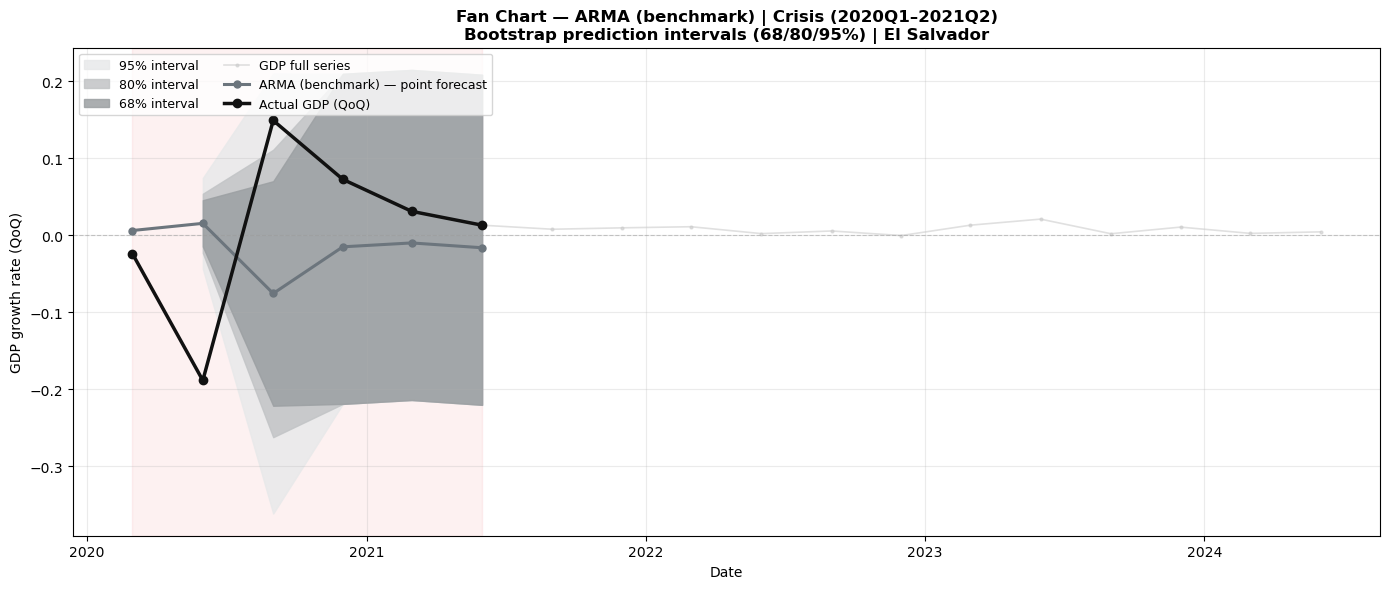

  Saved: fanchart_arma_crisis.png


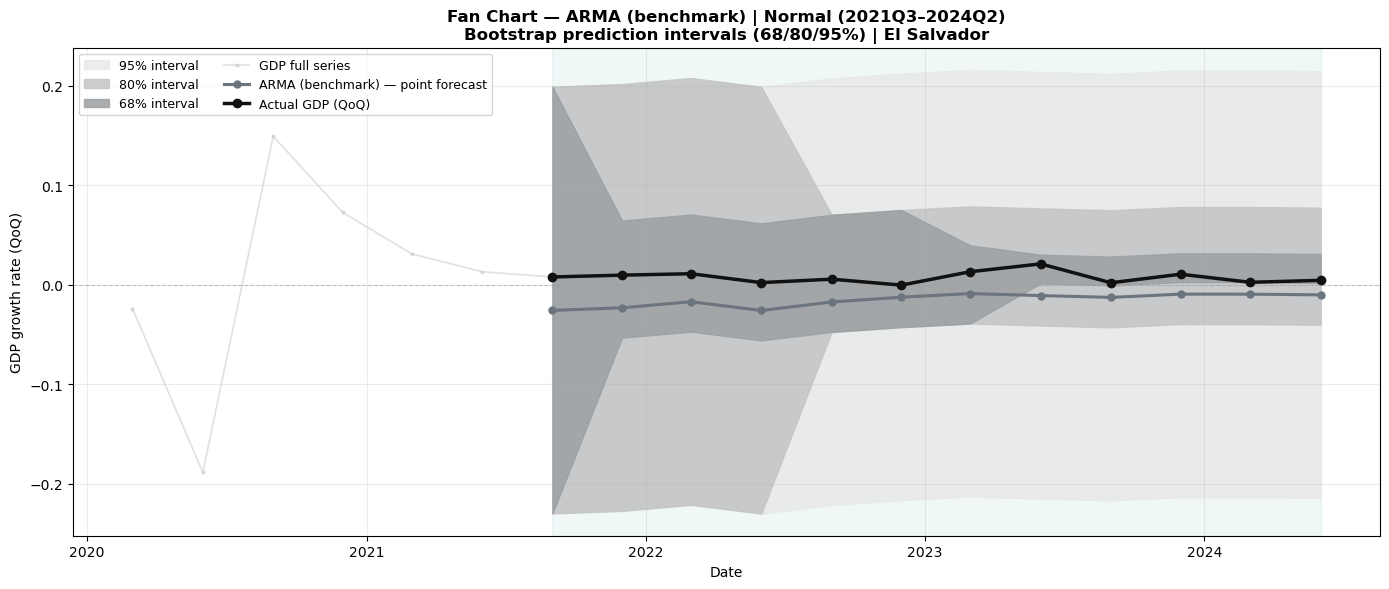

  Saved: fanchart_arma_normal.png


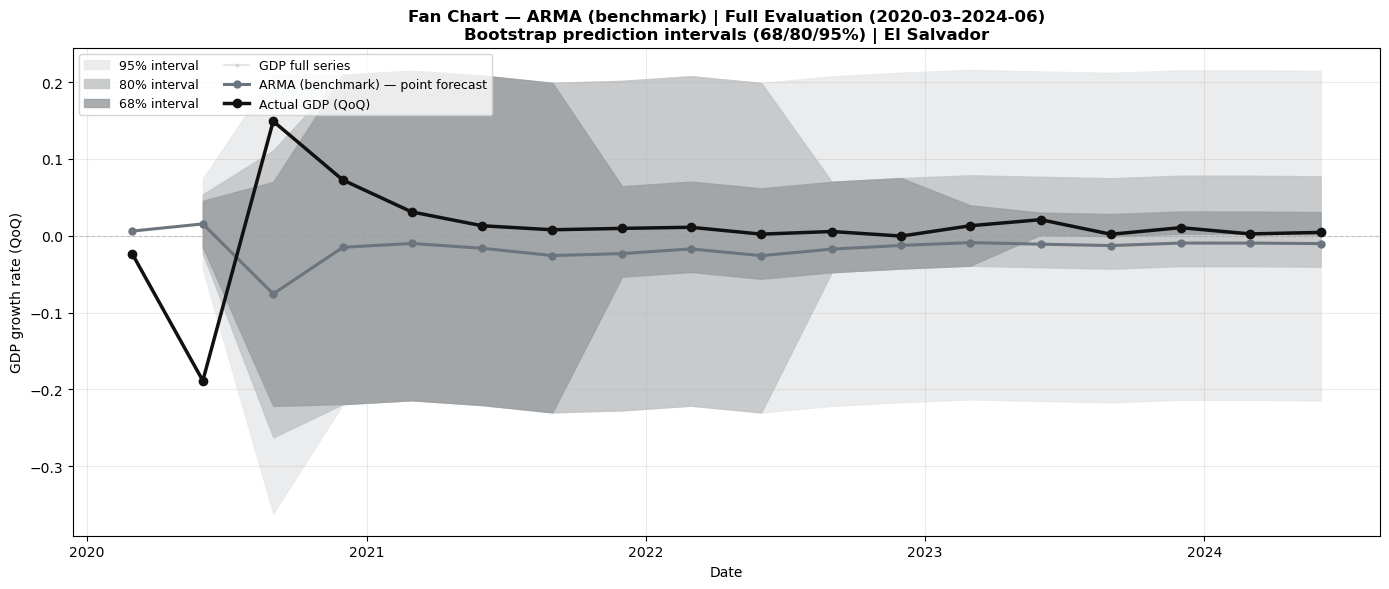

  Saved: fanchart_arma_full.png


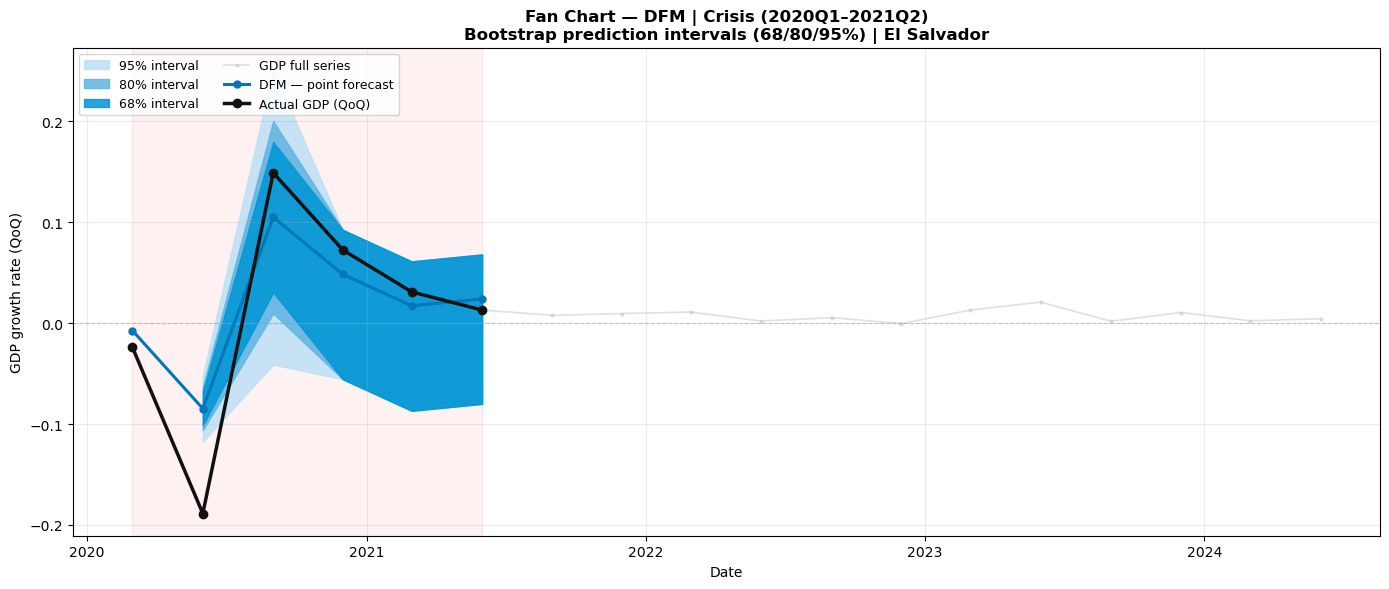

  Saved: fanchart_dfm_crisis.png


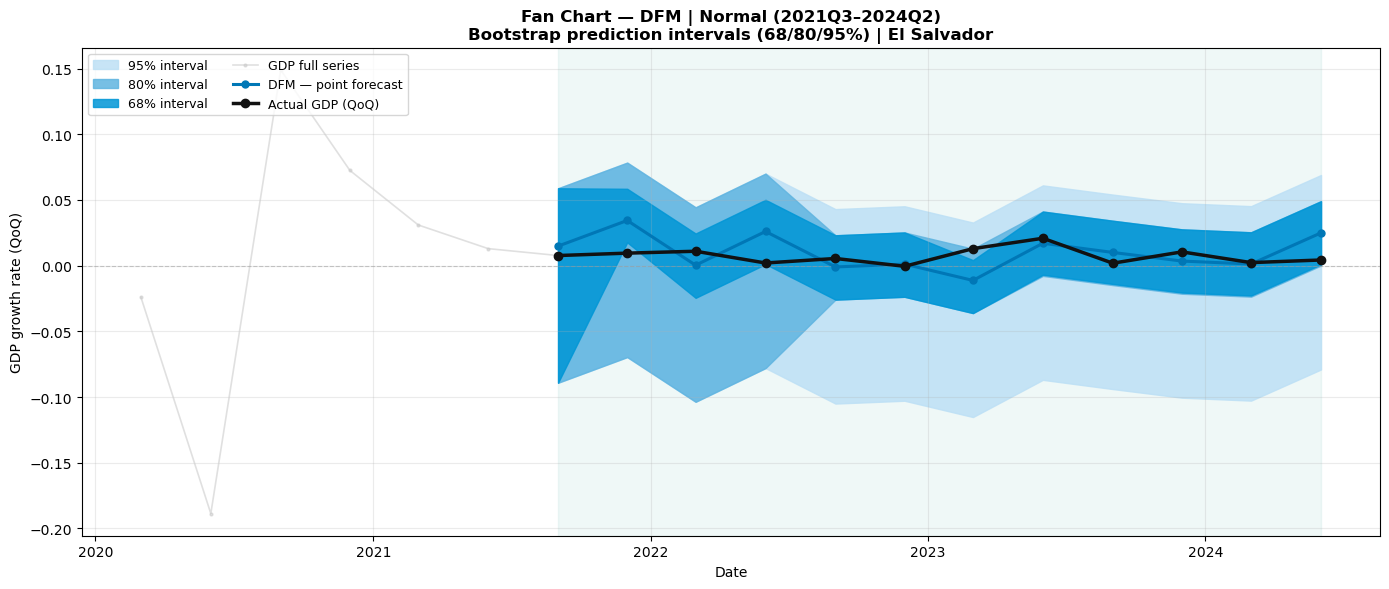

  Saved: fanchart_dfm_normal.png


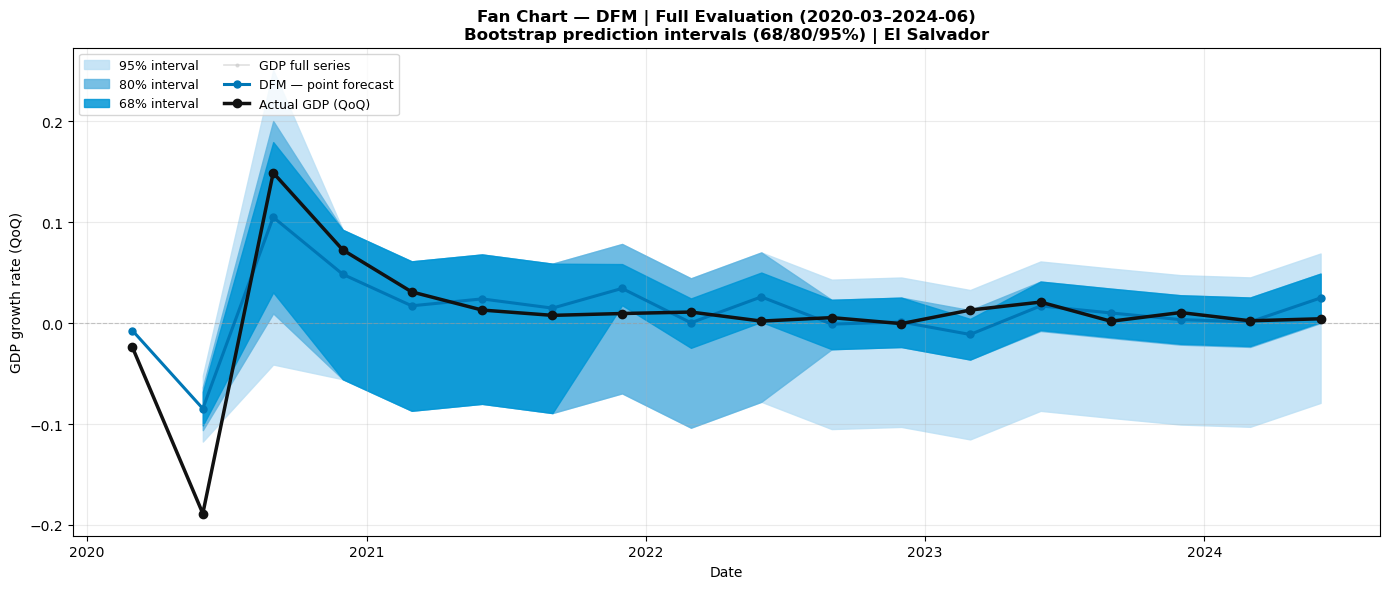

  Saved: fanchart_dfm_full.png


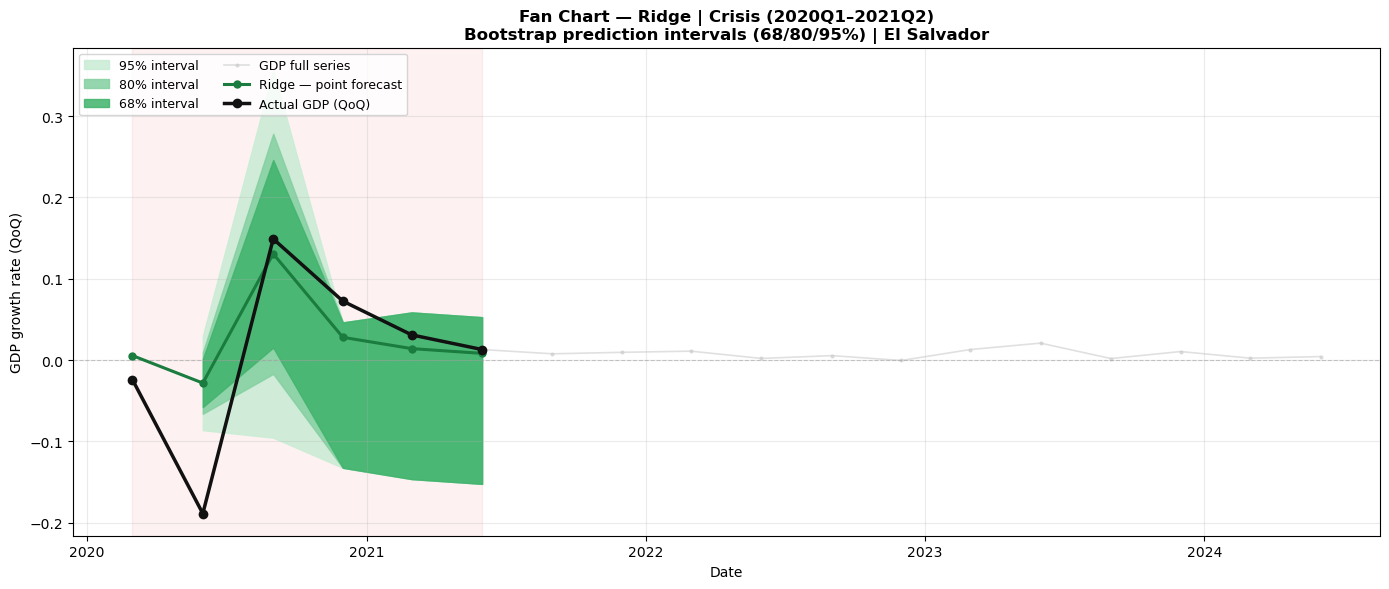

  Saved: fanchart_ridge_crisis.png


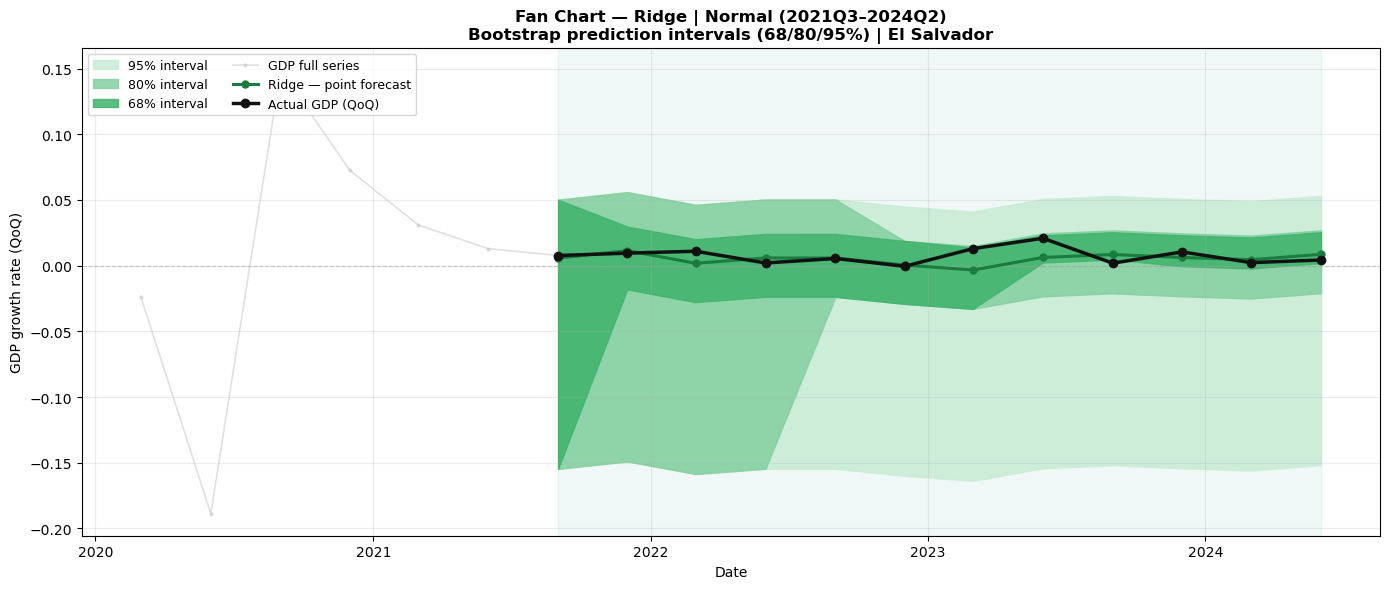

  Saved: fanchart_ridge_normal.png


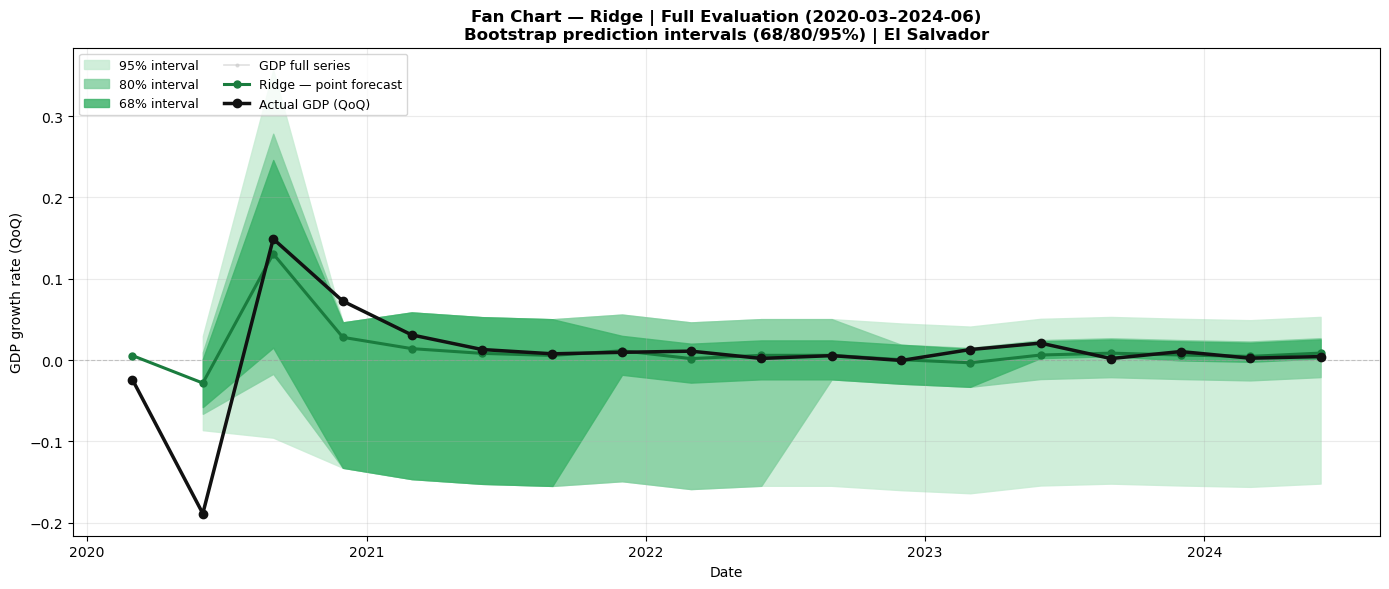

  Saved: fanchart_ridge_full.png


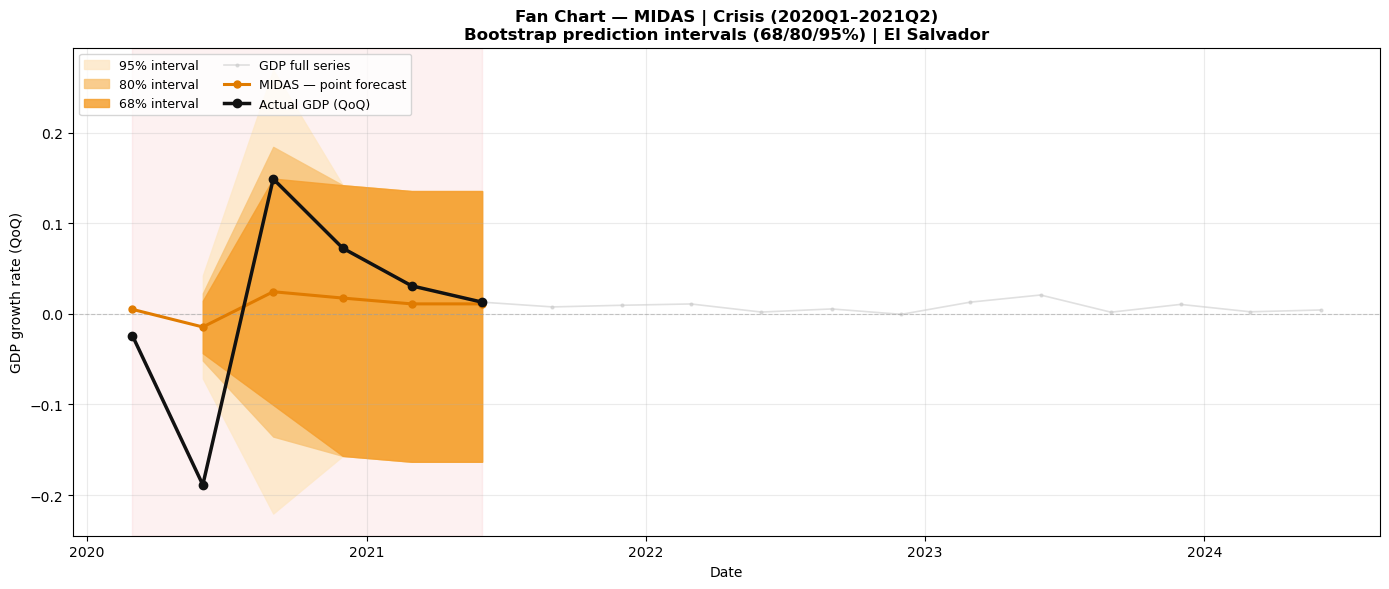

  Saved: fanchart_midas_crisis.png


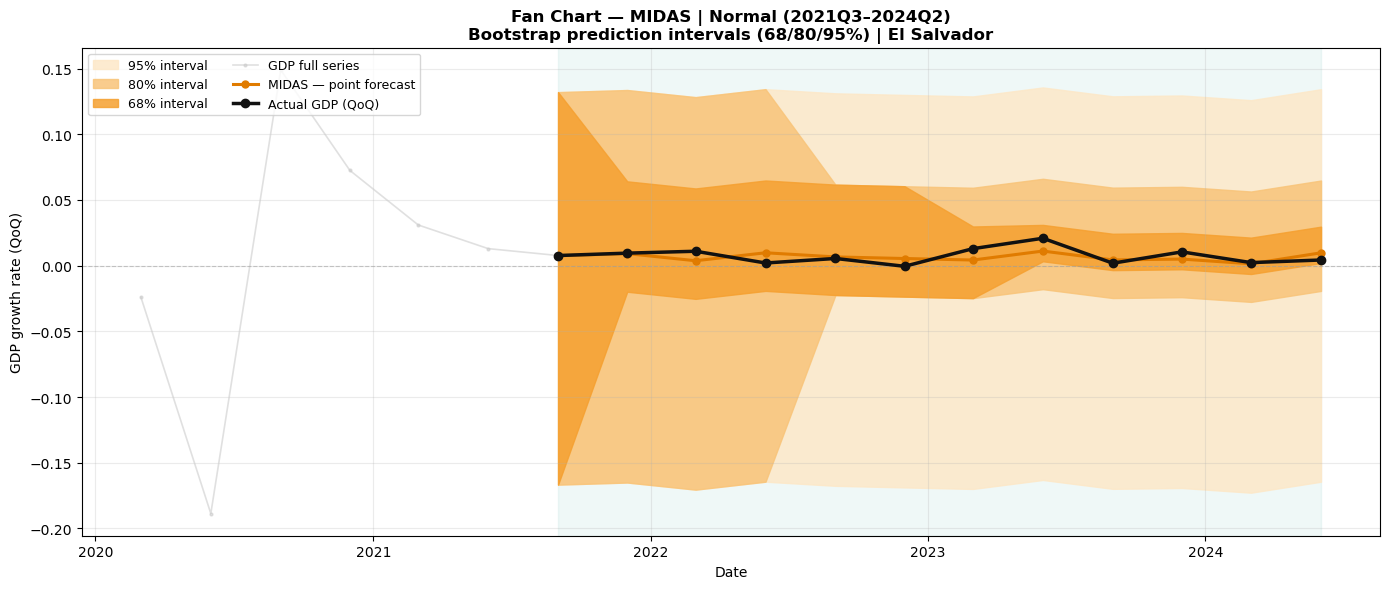

  Saved: fanchart_midas_normal.png


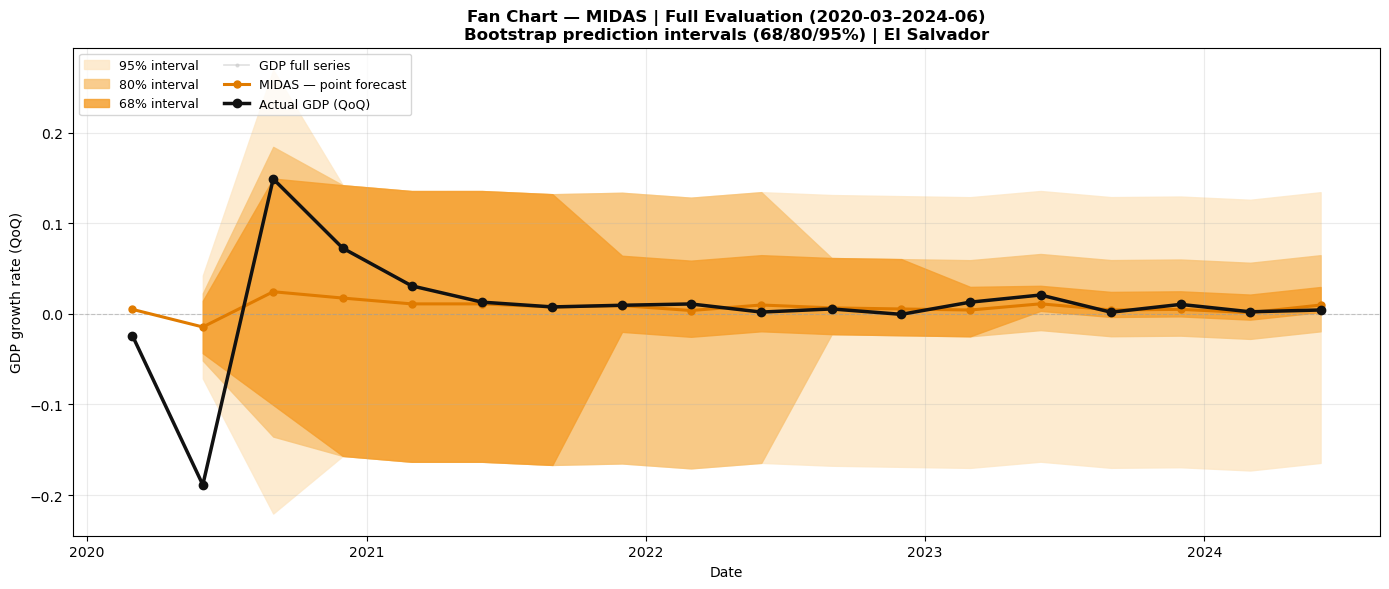

  Saved: fanchart_midas_full.png


In [20]:
# =============================================================================
# FAN CHART PLOTTING — bootstrap bands + point forecast + actuals
# =============================================================================

def plot_fanchart(model, mask, period_title, filename, period_key=None):
    style      = MODEL_STYLES[model]
    ints       = all_intervals[model]
    eval_dates = dates_dt[mask]
    eval_acts  = actuals[mask]
    eval_preds = preds_lag0[model][mask]
    full_valid = ~np.isnan(actuals)

    fig, ax = plt.subplots(figsize=(14, 6))

    # Shade evaluation window
    if period_key == "crisis":
        ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
                   alpha=0.07, color="#e63946", zorder=0)
    elif period_key == "normal":
        ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
                   alpha=0.07, color="#2a9d8f", zorder=0)

    # Bootstrap bands (widest to narrowest, so widest is behind)
    for i, lev in enumerate(sorted(LEVELS, reverse=True)):
        lo = ints[lev]["lower"][mask]; hi = ints[lev]["upper"][mask]
        ok = ~np.isnan(lo) & ~np.isnan(hi)
        ax.fill_between(eval_dates[ok], lo[ok], hi[ok],
                        color=style["band_colors"][i], alpha=0.85,
                        label=f"{int(lev*100)}% interval", zorder=1)

    # Full GDP series in grey (context)
    ax.plot(dates_dt[full_valid], actuals[full_valid],
            color="#cccccc", lw=1.2, marker="o", markersize=2,
            alpha=0.6, zorder=2, label="GDP full series")

    # Point forecast
    ok_p = ~np.isnan(eval_preds)
    ax.plot(eval_dates[ok_p], eval_preds[ok_p],
            color=style["point_color"], lw=2.2, marker="o", markersize=5,
            label=f"{style['label']} — point forecast", zorder=4)

    # Actuals in evaluation period
    ok_a = ~np.isnan(eval_acts)
    ax.plot(eval_dates[ok_a], eval_acts[ok_a],
            color="#111", lw=2.5, marker="o", markersize=6,
            label="Actual GDP (QoQ)", zorder=5)

    ax.axhline(0, color="#999", lw=0.8, ls="--", alpha=0.5)
    ax.set_xlabel("Date"); ax.set_ylabel("GDP growth rate (QoQ)")
    ax.set_title(f"Fan Chart — {style['label']} | {period_title}\n"
                 "Bootstrap prediction intervals (68/80/95%) | El Salvador",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, ncol=2, loc="upper left")
    ax.grid(True, alpha=0.25)
    format_xaxis(ax)
    plt.tight_layout()
    fig.savefig(OUT_FAN / filename, dpi=150, bbox_inches="tight")
    plt.show(); plt.close()
    print(f"  Saved: {filename}")

print("Generating fan charts...")
for model in fan_models:
    for mask, period_title, period_key in [
        (mask_crisis, "Crisis (2020Q1–2021Q2)",        "crisis"),
        (mask_normal, "Normal (2021Q3–2024Q2)",         "normal"),
        (mask_full,   f"Full Evaluation ({TEST_START[:7]}–{TEST_END[:7]})", "full"),
    ]:
        fname = f"fanchart_{model.lower().replace(' ', '_')}_{period_key}.png"
        plot_fanchart(model, mask, period_title, fname, period_key=period_key)


## Block 7 — Interval Width Over Time

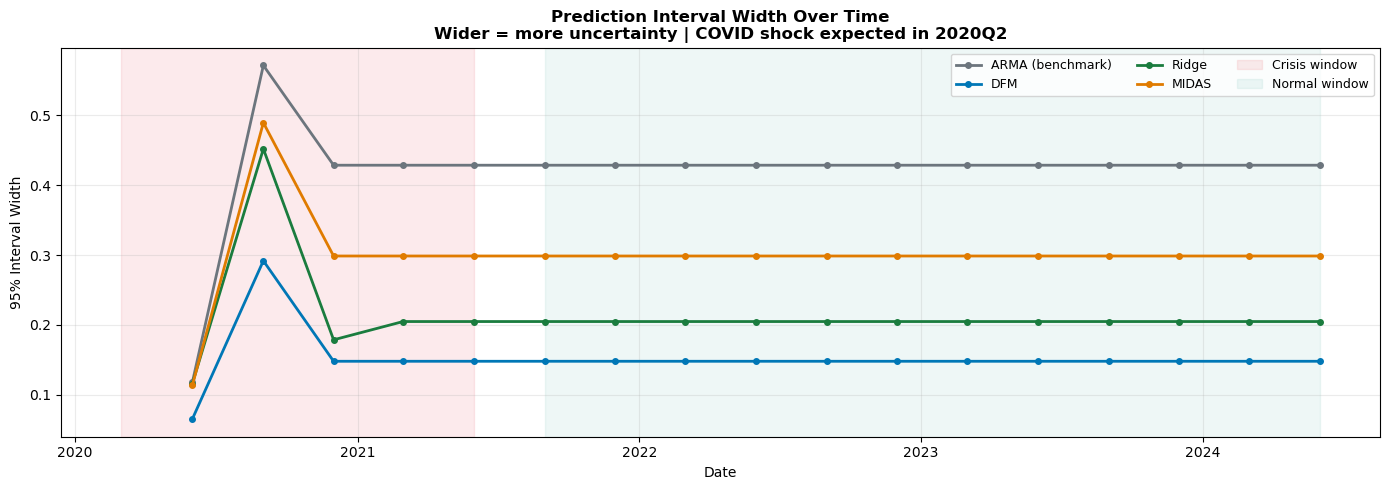

Saved: fanchart_interval_width.png
All fan chart outputs saved to: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/fanchart


In [21]:
# =============================================================================
# INTERVAL WIDTH OVER TIME — expect a spike around 2020Q2 (COVID)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))
for model in fan_models:
    lo    = all_intervals[model][0.95]["lower"]
    hi    = all_intervals[model][0.95]["upper"]
    width = hi - lo
    ok    = ~np.isnan(width)
    ax.plot(dates_dt[ok], width[ok],
            color=MODEL_STYLES[model]["point_color"], lw=2,
            marker="o", markersize=4, label=MODEL_STYLES[model]["label"])

ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.10, color="#e63946", label="Crisis window")
ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
           alpha=0.08, color="#2a9d8f", label="Normal window")

ax.set_xlabel("Date"); ax.set_ylabel("95% Interval Width")
ax.set_title("Prediction Interval Width Over Time\n"
             "Wider = more uncertainty | COVID shock expected in 2020Q2",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, ncol=3); ax.grid(True, alpha=0.25)
format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_FAN / "fanchart_interval_width.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fanchart_interval_width.png")
print("All fan chart outputs saved to:", OUT_FAN)


## Block 8 — CRPS (Density Forecast Evaluation)

Continuous Ranked Probability Score (Gneiting & Raftery 2007).
Uses the Gaussian closed form with `sigma` = rolling std of past residuals
(strictly pseudo-real-time — only past errors at each origin).

- CRPS reduces to RMSE when the forecast is a point (delta) distribution
- CRPS < RMSE when the predictive distribution adds calibration value
- A model winning on RMSE but losing on CRPS is **overconfident**


In [22]:
# =============================================================================
# CRPS SCORES — Gaussian closed form with rolling sigma
# =============================================================================

def gaussian_crps(y, mu, sigma):
    if any(np.isnan([y, mu, sigma])) or sigma <= 0:
        return np.nan
    z = (y - mu) / sigma
    return float(
        sigma * (z * (2 * stats.norm.cdf(z) - 1)
                 + 2 * stats.norm.pdf(z) - 1 / np.sqrt(np.pi))
    )

def rolling_sigma(errors, t, min_obs=MIN_RESIDUALS):
    past = errors[:t]
    past = past[~np.isnan(past)]
    return float(np.std(past, ddof=1)) if len(past) >= min_obs else np.nan

print("Computing CRPS scores...")
crps_scores = {}
for model in available:
    yhat   = preds_lag0[model]
    errs   = actuals - yhat
    scores = np.full(len(actuals), np.nan)
    for t in range(len(actuals)):
        scores[t] = gaussian_crps(actuals[t], yhat[t], rolling_sigma(errs, t))
    crps_scores[model] = scores
    print(f"  [{model}] mean CRPS = {np.nanmean(scores):.6f}")

def mean_crps(model, mask):
    s = crps_scores[model][mask]
    return float(np.nanmean(s)) if (~np.isnan(s)).sum() > 0 else np.nan

crps_rows = []
for model in available:
    for mask, period in [
        (mask_full,   "Full"),
        (mask_crisis, "Crisis"),
        (mask_normal, "Normal"),
    ]:
        crps_rows.append({
            "Model":  model,
            "Period": period,
            "CRPS":   round(mean_crps(model, mask), 6),
            "n":      int((~np.isnan(crps_scores[model][mask])).sum()),
        })

crps_df = pd.DataFrame(crps_rows)

# Relative CRPS and CRPS Skill Score (CRPSS) vs ARMA
if "ARMA" in available:
    arma_c = {r["Period"]: r["CRPS"]
              for _, r in crps_df[crps_df["Model"] == "ARMA"].iterrows()}
    crps_df["rel_CRPS"] = crps_df.apply(
        lambda r: round(r["CRPS"] / arma_c[r["Period"]], 4)
        if arma_c.get(r["Period"]) else np.nan, axis=1)
    crps_df["CRPSS"] = (1 - crps_df["rel_CRPS"]).round(4)

crps_pivot  = (crps_df.pivot(index="Model", columns="Period", values="rel_CRPS")
               [["Crisis", "Normal", "Full"]].round(4)
               .sort_values("Full"))
crpss_pivot = (crps_df.pivot(index="Model", columns="Period", values="CRPSS")
               [["Crisis", "Normal", "Full"]].round(4))

print("\nRELATIVE CRPS (ARMA = 1, lower = better density forecast):")
print(crps_pivot.to_string())
print("\nCRPS SKILL SCORE (positive = better density than ARMA):")
print(crpss_pivot.to_string())

crps_df.to_csv(   OUT_CRPS / "crps_scores.csv",         index=False)
crps_pivot.to_csv(OUT_CRPS / "crps_relative_table.csv")
crpss_pivot.to_csv(OUT_CRPS / "crpss_skill_table.csv")


Computing CRPS scores...
  [ARMA] mean CRPS = 0.030771
  [DFM] mean CRPS = 0.012404
  [Ridge] mean CRPS = 0.015334
  [MIDAS] mean CRPS = 0.020393
  [Lasso] mean CRPS = 0.020399
  [Random Forest] mean CRPS = 0.023037
  [XGBoost] mean CRPS = 0.022931

RELATIVE CRPS (ARMA = 1, lower = better density forecast):
Period         Crisis  Normal    Full
Model                                
DFM            0.3435  0.4317  0.4031
Ridge          0.4797  0.5073  0.4983
MIDAS          0.6708  0.6589  0.6627
Lasso          0.6605  0.6641  0.6629
XGBoost        0.7485  0.7436  0.7452
Random Forest  0.7608  0.7428  0.7487
ARMA           1.0000  1.0000  1.0000

CRPS SKILL SCORE (positive = better density than ARMA):
Period         Crisis  Normal    Full
Model                                
ARMA           0.0000  0.0000  0.0000
DFM            0.6565  0.5683  0.5969
Lasso          0.3395  0.3359  0.3371
MIDAS          0.3292  0.3411  0.3373
Random Forest  0.2392  0.2572  0.2513
Ridge          0.5203  0.4

## Block 9 — CRPS Plots

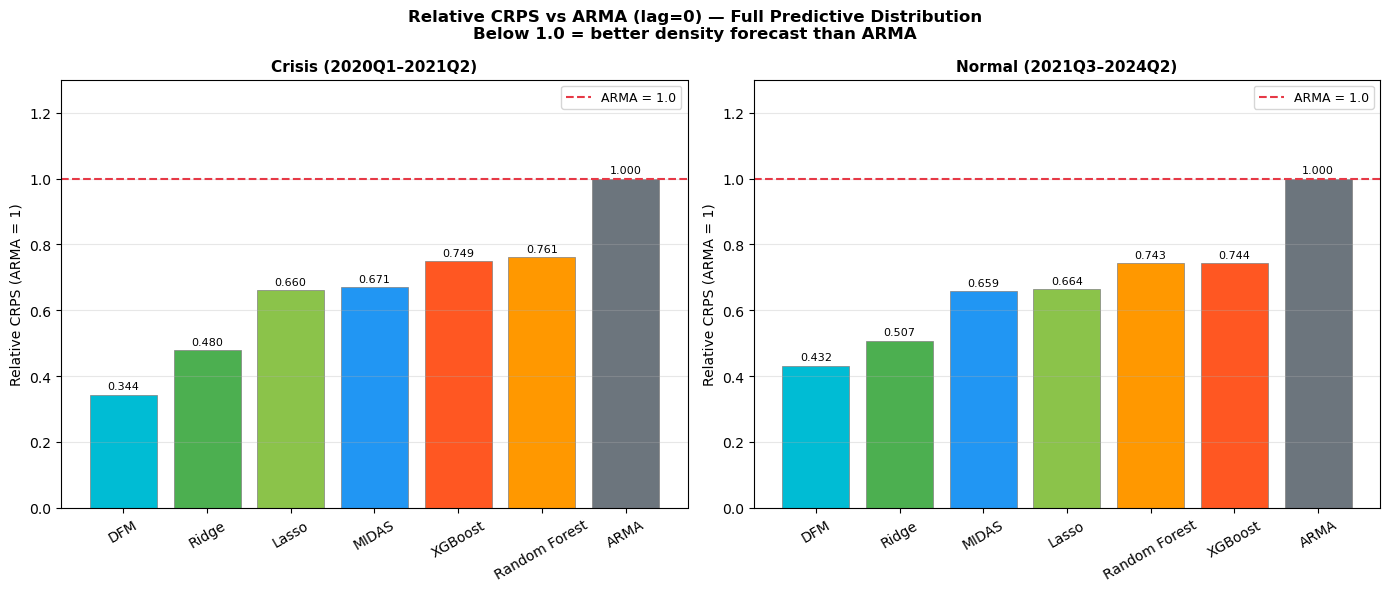

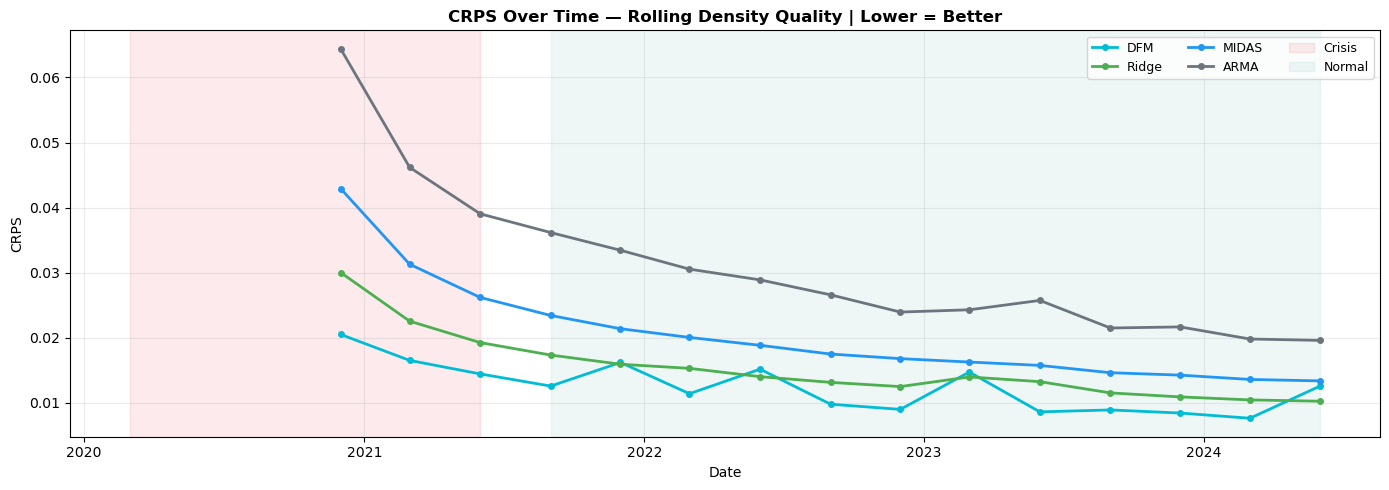

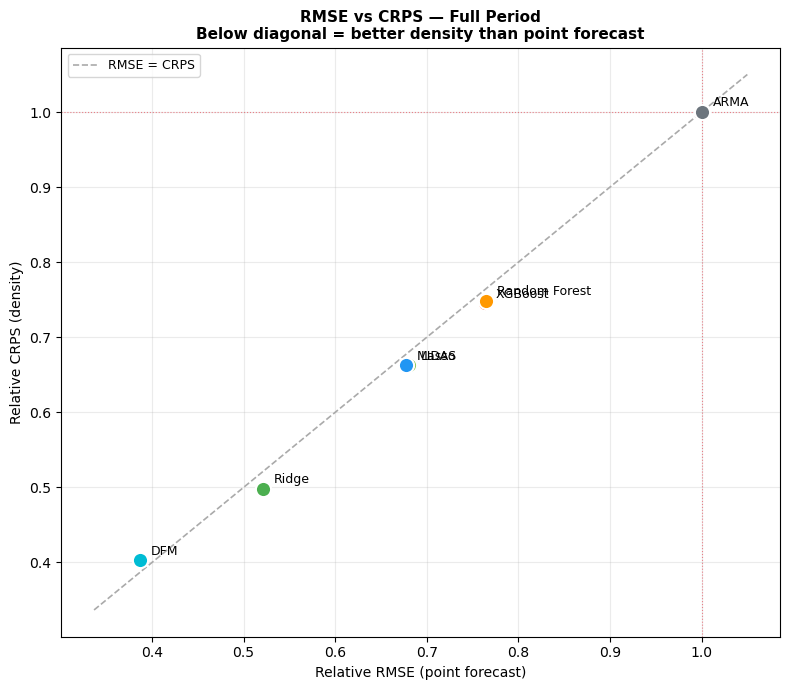


All CRPS outputs saved to: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/crps


In [23]:
# =============================================================================
# CRPS PLOTS
# =============================================================================

# --- Plot 1: CRPS bar chart — crisis vs normal -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Relative CRPS vs ARMA (lag=0) — Full Predictive Distribution\n"
             "Below 1.0 = better density forecast than ARMA",
             fontsize=12, fontweight="bold")
for ax, period, title in zip(
    axes, ["Crisis", "Normal"],
    ["Crisis (2020Q1–2021Q2)", "Normal (2021Q3–2024Q2)"]
):
    sub  = crps_df[crps_df["Period"] == period].sort_values("rel_CRPS")
    bars = ax.bar(sub["Model"], sub["rel_CRPS"],
                  color=[MODEL_COLORS.get(m, "#888") for m in sub["Model"]],
                  edgecolor="gray", lw=0.5)
    ax.axhline(1.0, color="#e63946", lw=1.5, ls="--", label="ARMA = 1.0")
    for bar, val in zip(bars, sub["rel_CRPS"]):
        if not pd.isna(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Relative CRPS (ARMA = 1)")
    ymax = sub["rel_CRPS"].max() if not sub["rel_CRPS"].isna().all() else 1.3
    ax.set_ylim(0, max(ymax * 1.2, 1.3))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(OUT_CRPS / "crps_plot1_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 2: CRPS over time --------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 5))
for model in ["DFM", "Ridge", "MIDAS", "ARMA"]:
    if model not in crps_scores:
        continue
    ok = ~np.isnan(crps_scores[model])
    ax.plot(dates_dt[ok], crps_scores[model][ok],
            color=MODEL_COLORS.get(model, "#888"), lw=2,
            marker="o", markersize=4, label=model)
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.10, color="#e63946", label="Crisis")
ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
           alpha=0.08, color="#2a9d8f", label="Normal")
ax.set_xlabel("Date"); ax.set_ylabel("CRPS")
ax.set_title("CRPS Over Time — Rolling Density Quality | Lower = Better",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, ncol=3); ax.grid(True, alpha=0.25)
format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_CRPS / "crps_plot2_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 3: RMSE vs CRPS scatter (consistency check) ------------------------
rmse_path = RES_DIR / "comparison" / "rel_rmse_full.csv"
if rmse_path.exists():
    rmse_full  = pd.read_csv(rmse_path, index_col=0)
    rmse_nw    = rmse_full["lag=0 (nowcast)"].rename("rel_RMSE")
    crps_full_s = crps_df[crps_df["Period"] == "Full"].set_index("Model")["rel_CRPS"]
    comp = pd.concat([rmse_nw, crps_full_s], axis=1).dropna()
    comp["RMSE_rank"] = comp["rel_RMSE"].rank()
    comp["CRPS_rank"] = comp["rel_CRPS"].rank()
    comp["Rank_diff"] = (comp["CRPS_rank"] - comp["RMSE_rank"]).astype(int)
    comp.to_csv(OUT_CRPS / "rmse_vs_crps_comparison.csv")

    fig, ax = plt.subplots(figsize=(8, 7))
    for model, row in comp.iterrows():
        ax.scatter(row["rel_RMSE"], row["rel_CRPS"],
                   color=MODEL_COLORS.get(model, "#888"), s=120, zorder=5,
                   edgecolors="white", lw=1.5)
        ax.annotate(model, (row["rel_RMSE"], row["rel_CRPS"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9)
    arr  = comp[["rel_RMSE", "rel_CRPS"]].values
    lims = [float(arr.min()) - 0.05, float(arr.max()) + 0.05]
    ax.plot(lims, lims, color="#aaa", ls="--", lw=1.2, label="RMSE = CRPS")
    ax.axhline(1.0, color="#e63946", lw=0.8, ls=":", alpha=0.6)
    ax.axvline(1.0, color="#e63946", lw=0.8, ls=":", alpha=0.6)
    ax.set_xlabel("Relative RMSE (point forecast)")
    ax.set_ylabel("Relative CRPS (density)")
    ax.set_title("RMSE vs CRPS — Full Period\n"
                 "Below diagonal = better density than point forecast",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
    plt.tight_layout()
    fig.savefig(OUT_CRPS / "crps_plot3_rmse_vs_crps.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"  {rmse_path} not found — RMSE vs CRPS scatter skipped")

print("\nAll CRPS outputs saved to:", OUT_CRPS)


## Block 10 — Ridge Coefficient Analysis

**Reads `ridge_feature_importance.csv` produced by `Ridge.py`.**
This ensures the coefficients shown correspond to the *same Ridge model*
that produced `ridge_predictions.csv`. No re-estimation here.


Loaded 610 Ridge coefficients from ridge_feature_importance.csv

Top 20 Ridge coefficients (by |coef|):
  clean_name  coefficient
      GDP_IN     0.000219
      GDP_CP     0.000212
      GDP_AS     0.000203
      GDP_AE     0.000192
    IPI_US_2     0.000191
    IPM_US_2     0.000189
      GDP_TA     0.000189
      GDP_CO     0.000188
      GDP_OA     0.000188
   UNEM_US_2    -0.000180
   IVAE_IN_2     0.000179
       IPI_2     0.000179
UNEM_US_LA_2    -0.000177
   UNEM_US_3    -0.000174
      IMP_MP    -0.000170
  IVAE_TOT_2     0.000168
  IVAE_TOT_3     0.000168
       IPI_3     0.000164
   IVAE_IN_3     0.000163
    EXP_MP_2     0.000162


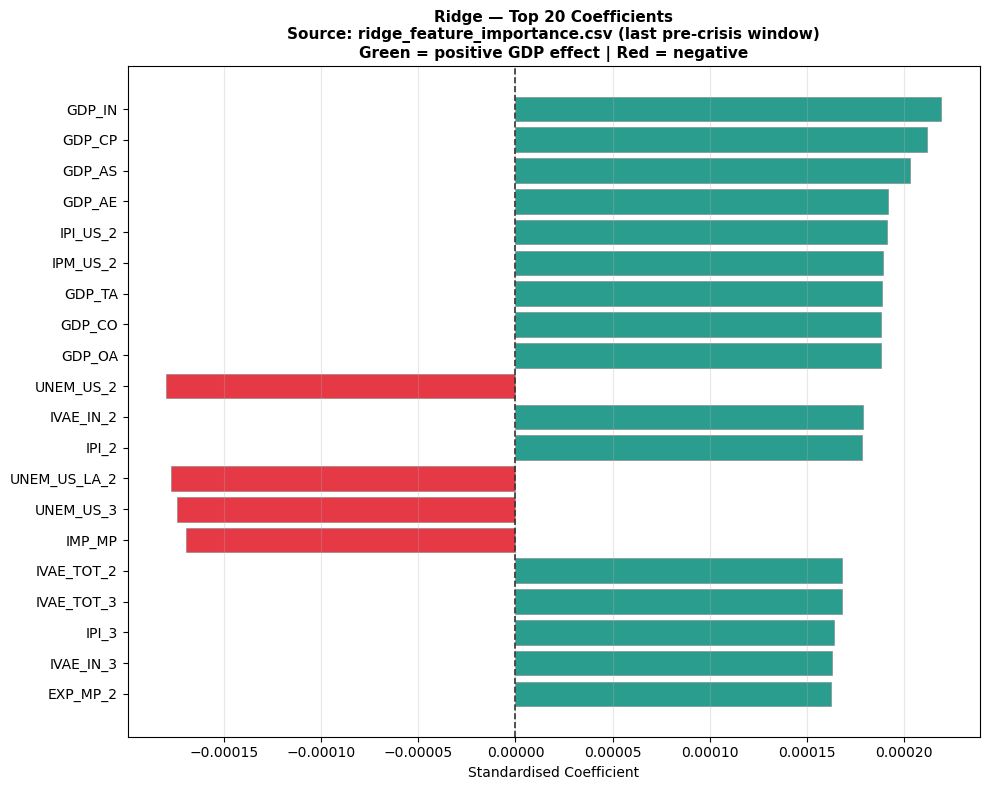


Saved: ridge_coefficients_top20.png


In [24]:
# =============================================================================
# RIDGE COEFFICIENTS — from Ridge.py output (single source of truth)
# =============================================================================

def clean_name(f):
    """Pretty-print feature names like 'GDP_lag2' -> 'GDP (lag 2)'."""
    parts = str(f).rsplit("_lag", 1)
    return f"{parts[0]} (lag {parts[1]})" if len(parts) == 2 else str(f)

RIDGE_CSV = RES_DIR / "ridge" / "ridge_feature_importance.csv"
if not RIDGE_CSV.exists():
    raise FileNotFoundError(
        f"Ridge feature importance not found at {RIDGE_CSV}\n"
        "Run Ridge.py first to generate this file."
    )

ridge_coefs = pd.read_csv(RIDGE_CSV)

# Normalise column names: Ridge.py should output 'feature' and 'coefficient'
# (and 'abs_coef'). Handle a couple of possible variations.
cols_lower = {c.lower(): c for c in ridge_coefs.columns}
if "coefficient" not in cols_lower:
    raise ValueError(f"Expected a 'coefficient' column in {RIDGE_CSV.name}; "
                     f"found {list(ridge_coefs.columns)}")

feature_col = cols_lower.get("feature", list(ridge_coefs.columns)[0])
coef_col    = cols_lower["coefficient"]
ridge_coefs = ridge_coefs.rename(columns={feature_col: "feature",
                                          coef_col:    "coefficient"})

if "abs_coef" not in ridge_coefs.columns:
    ridge_coefs["abs_coef"] = ridge_coefs["coefficient"].abs()
ridge_coefs["clean_name"] = ridge_coefs["feature"].apply(clean_name)
ridge_coefs = ridge_coefs.sort_values("abs_coef", ascending=False)

print(f"Loaded {len(ridge_coefs)} Ridge coefficients from {RIDGE_CSV.name}")
print("\nTop 20 Ridge coefficients (by |coef|):")
print(ridge_coefs[["clean_name", "coefficient"]].head(20).to_string(index=False))

# Plot
top_r  = ridge_coefs.head(20)
colors = ["#2a9d8f" if c > 0 else "#e63946" for c in top_r["coefficient"]]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_r["clean_name"][::-1], top_r["coefficient"][::-1],
        color=colors[::-1], edgecolor="gray", lw=0.4)
ax.axvline(0, color="#333", lw=1.2, ls="--")
ax.set_xlabel("Standardised Coefficient")
ax.set_title("Ridge — Top 20 Coefficients\n"
             "Source: ridge_feature_importance.csv (last pre-crisis window)\n"
             "Green = positive GDP effect | Red = negative",
             fontsize=11, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_INTERP / "ridge_coefficients_top20.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: ridge_coefficients_top20.png")


## Block 11 — Lasso Coefficients and Rolling Selection Frequency

Reads two CSVs produced by `Lasso.py`:
- `lasso_feature_importance.csv` — coefficients from a single representative window
- `lasso_selection_frequency.csv` — how often each variable was selected across the 18 rolling windows

Rolling frequency is the key interpretability output: a variable selected
in ≥50% of windows is a robust indicator for GDP nowcasting.


Loaded 610 Lasso coefficients from lasso_feature_importance.csv
  Non-zero in representative window: 77


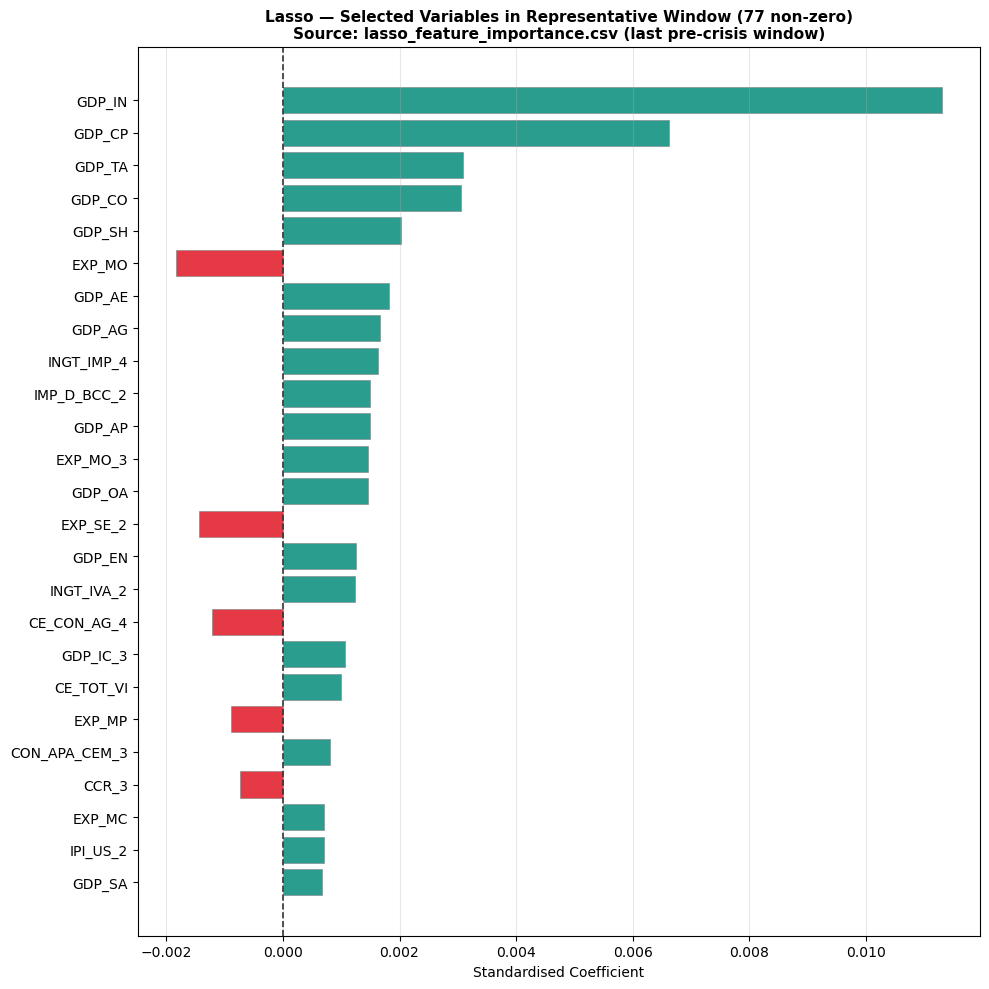

Saved: lasso_selected_variables.png

Loaded Lasso rolling frequency: 122 variables across 18 windows (from lasso_selection_frequency.csv)

Variables selected in >=50% of windows (31):
   94.4%  GDP_IN  (avg|coef| = 0.0084)
   94.4%  GDP_CP  (avg|coef| = 0.0054)
   88.9%  GDP_TA  (avg|coef| = 0.0028)
   88.9%  GDP_CO  (avg|coef| = 0.0022)
   83.3%  GDP_AE  (avg|coef| = 0.0014)
   83.3%  IPI_US_2  (avg|coef| = 0.0012)
   83.3%  IVAE_TOT_3  (avg|coef| = 0.0011)
   77.8%  GDP_OA  (avg|coef| = 0.0012)
   72.2%  GDP_SH  (avg|coef| = 0.0013)
   66.7%  GDP_AP  (avg|coef| = 0.0006)
   61.1%  EXP_MO  (avg|coef| = 0.0008)
   61.1%  GDP_AG  (avg|coef| = 0.0007)
   61.1%  GDP_IC_3  (avg|coef| = 0.0006)
   61.1%  GDP_AS  (avg|coef| = 0.0006)
   61.1%  INGT_IVA_2  (avg|coef| = 0.0005)
   61.1%  CON_APA_CEM_3  (avg|coef| = 0.0004)
   55.6%  CCO_1  (avg|coef| = 0.0003)
   55.6%  IMP_CP_3  (avg|coef| = 0.0003)
   55.6%  INGT_IMP_4  (avg|coef| = 0.0005)
   55.6%  CE_CON_AG_4  (avg|coef| = 0.0006)


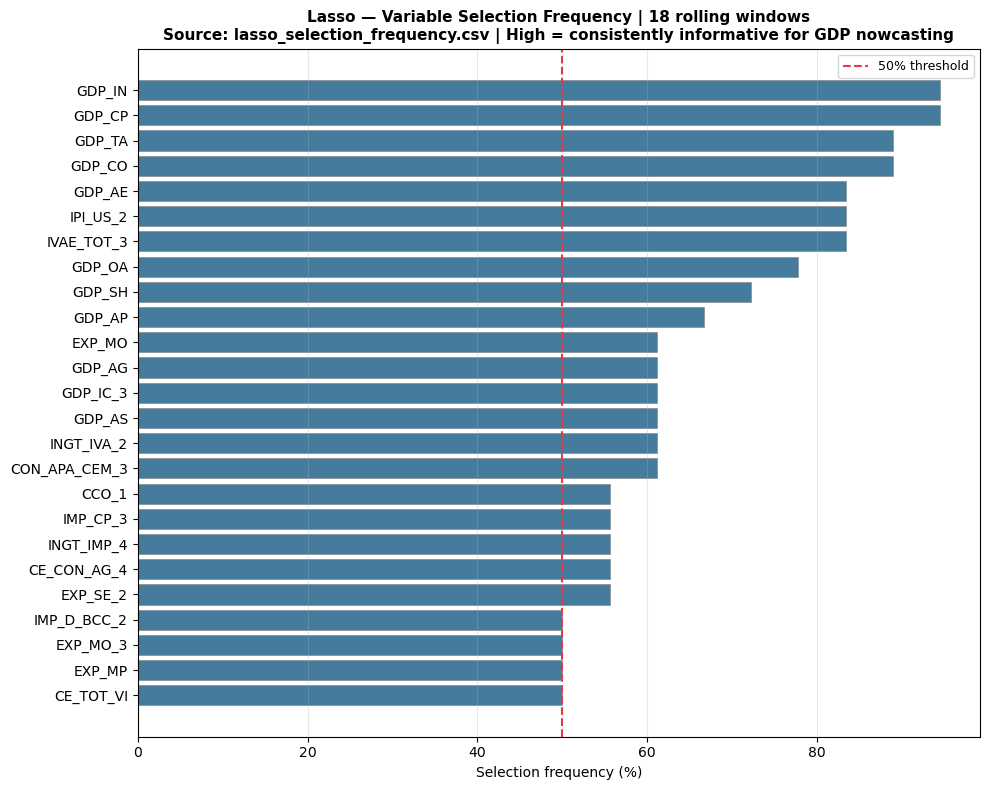

Saved: lasso_selection_frequency.png


In [25]:
# =============================================================================
# LASSO — single-window coefficients + rolling selection frequency
# Both CSVs are produced by the (fixed) Lasso.py. No re-estimation here.
# =============================================================================

LASSO_IMP_CSV  = RES_DIR / "lasso" / "lasso_feature_importance.csv"
LASSO_FREQ_CSV = RES_DIR / "lasso" / "lasso_selection_frequency.csv"

# --- Single-window coefficients ---------------------------------------------
if LASSO_IMP_CSV.exists():
    lasso_coefs = pd.read_csv(LASSO_IMP_CSV)
    cols_lower  = {c.lower(): c for c in lasso_coefs.columns}
    lasso_coefs = lasso_coefs.rename(columns={
        cols_lower.get("feature",     list(lasso_coefs.columns)[0]): "feature",
        cols_lower.get("coefficient", cols_lower.get("coef", list(lasso_coefs.columns)[1])): "coefficient",
    })
    if "abs_coef" not in lasso_coefs.columns:
        lasso_coefs["abs_coef"] = lasso_coefs["coefficient"].abs()
    lasso_coefs["clean_name"] = lasso_coefs["feature"].apply(clean_name)
    lasso_coefs = lasso_coefs.sort_values("abs_coef", ascending=False)
    sel = lasso_coefs[lasso_coefs["coefficient"] != 0].reset_index(drop=True)
    n_sel_window = len(sel)
    print(f"Loaded {len(lasso_coefs)} Lasso coefficients from {LASSO_IMP_CSV.name}")
    print(f"  Non-zero in representative window: {n_sel_window}")

    if n_sel_window > 0:
        top_n    = min(25, n_sel_window)
        colors_l = ["#2a9d8f" if c > 0 else "#e63946"
                    for c in sel["coefficient"].head(top_n)]
        fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.4)))
        ax.barh(sel["clean_name"].head(top_n)[::-1],
                sel["coefficient"].head(top_n)[::-1],
                color=colors_l[::-1], edgecolor="gray", lw=0.4)
        ax.axvline(0, color="#333", lw=1.2, ls="--")
        ax.set_xlabel("Standardised Coefficient")
        ax.set_title(f"Lasso — Selected Variables in Representative Window "
                     f"({n_sel_window} non-zero)\n"
                     "Source: lasso_feature_importance.csv (last pre-crisis window)",
                     fontsize=11, fontweight="bold")
        ax.grid(True, axis="x", alpha=0.3)
        plt.tight_layout()
        fig.savefig(OUT_INTERP / "lasso_selected_variables.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: lasso_selected_variables.png")
else:
    lasso_coefs = None
    print(f"  {LASSO_IMP_CSV} not found — single-window plot skipped")

# --- Rolling selection frequency --------------------------------------------
if not LASSO_FREQ_CSV.exists():
    raise FileNotFoundError(
        f"Lasso rolling frequency CSV not found at {LASSO_FREQ_CSV}\n"
        "Run Lasso.py first — it now generates lasso_selection_frequency.csv."
    )

freq_df = pd.read_csv(LASSO_FREQ_CSV)
freq_df["clean_name"] = freq_df["feature"].apply(clean_name)
freq_df = freq_df[freq_df["freq_pct"] > 0].sort_values("freq_pct", ascending=False)

n_total_windows = int(freq_df["n_windows"].iloc[0]) if len(freq_df) > 0 else 0
print(f"\nLoaded Lasso rolling frequency: {len(freq_df)} variables across "
      f"{n_total_windows} windows (from {LASSO_FREQ_CSV.name})")

# Robust indicators (≥50% selection frequency)
robust = freq_df[freq_df["freq_pct"] >= 50]
print(f"\nVariables selected in >=50% of windows ({len(robust)}):")
for _, r in robust.head(20).iterrows():
    print(f"  {r['freq_pct']:5.1f}%  {r['clean_name']}  "
          f"(avg|coef| = {r['avg_abs_coef']:.4f})")

# Plot
top_freq = freq_df.head(25)
fig, ax  = plt.subplots(figsize=(10, 8))
ax.barh(top_freq["clean_name"][::-1], top_freq["freq_pct"][::-1],
        color="#457b9d", edgecolor="gray", lw=0.4)
ax.axvline(50, color="#e63946", lw=1.5, ls="--", label="50% threshold")
ax.set_xlabel("Selection frequency (%)")
ax.legend(fontsize=9)
ax.set_title(f"Lasso — Variable Selection Frequency | {n_total_windows} rolling windows\n"
             "Source: lasso_selection_frequency.csv | "
             "High = consistently informative for GDP nowcasting",
             fontsize=11, fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_INTERP / "lasso_selection_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lasso_selection_frequency.png")


## Block 12 — XGBoost SHAP Analysis

Reads `xgboost_shap_importance.csv` and the pre-computed SHAP PNGs produced
by `XGBoost.py`. The SHAP analysis runs on the same last pre-crisis window
that produced `xgboost_feature_importance.csv`, so the two rankings are
directly comparable. No re-estimation here.


In [26]:
# =============================================================================
# XGBOOST SHAP — from XGBoost.py output
# =============================================================================

SHAP_CSV       = RES_DIR / "xgboost" / "xgboost_shap_importance.csv"
SHAP_BAR_PNG   = RES_DIR / "xgboost" / "xgboost_shap_bar.png"
SHAP_BEES_PNG  = RES_DIR / "xgboost" / "xgboost_shap_beeswarm.png"

if SHAP_CSV.exists():
    shap_imp = pd.read_csv(SHAP_CSV)
    shap_imp["clean_name"] = shap_imp["feature"].apply(clean_name)
    shap_imp = shap_imp.sort_values("mean_abs_shap", ascending=False)
    print(f"Loaded SHAP importance: {len(shap_imp)} features from {SHAP_CSV.name}")
    print("\nTop 20 features by mean |SHAP|:")
    print(shap_imp[["clean_name", "mean_abs_shap"]].head(20).to_string(index=False))

    # Display the pre-generated PNGs (bar and beeswarm)
    from PIL import Image
    for png_path, label in [
        (SHAP_BAR_PNG,  "SHAP Bar (top 20)"),
        (SHAP_BEES_PNG, "SHAP Bee-swarm"),
    ]:
        if png_path.exists():
            img = Image.open(png_path)
            fig, ax = plt.subplots(figsize=(12, 10))
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(f"XGBoost — {label}  (source: {png_path.name})",
                         fontsize=10)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  WARNING: {png_path} not found. Re-run XGBoost.py with shap installed.")
else:
    shap_imp = None
    print(f"  {SHAP_CSV} not found.")
    print("  Run XGBoost.py with shap installed: pip install shap")


  /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/xgboost/xgboost_shap_importance.csv not found.
  Run XGBoost.py with shap installed: pip install shap


## Block 13 — Cross-Model Variable Importance

Combines Ridge, Lasso (rolling freq ≥50%), and XGBoost SHAP (top 20)
into a single comparison. Variables appearing in all three are the
most robust leading indicators for El Salvador GDP nowcasting.


Cross-model agreement:
  Ridge  top 20   : 20 features
  Lasso  >=50% freq: 31 features
  XGBoost top 20 SHAP: 0 features

Variables in ALL three models (0):

Variables in Ridge + Lasso only:
  GDP_AE
  GDP_AS
  GDP_CO
  GDP_CP
  GDP_IN
  GDP_OA
  GDP_TA
  IPI_US_2
  IVAE_TOT_2
  IVAE_TOT_3

Variables in Ridge + XGBoost only:

Variables in Lasso + XGBoost only:


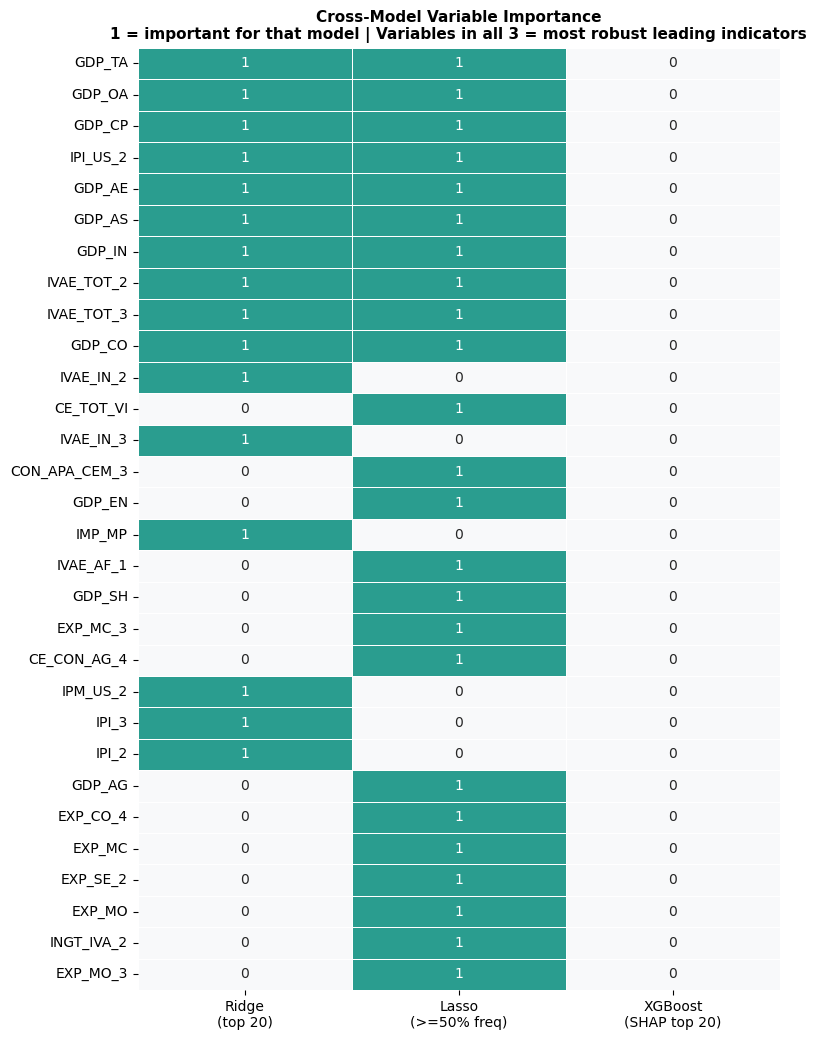


Saved: cross_model_importance.png

All interpretability outputs saved to: /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/interpretability

NOTEBOOK 02 COMPLETE


In [27]:
# =============================================================================
# CROSS-MODEL IMPORTANCE — synthesises Ridge, Lasso, XGBoost interpretability
# =============================================================================

# Build union of all features across the three sources
all_features = set()
if ridge_coefs is not None:
    all_features.update(ridge_coefs["feature"])
all_features.update(freq_df["feature"])
if shap_imp is not None:
    all_features.update(shap_imp["feature"])

all_features = sorted(all_features)

# Membership sets
ridge_top = set(ridge_coefs.head(20)["feature"]) if ridge_coefs is not None else set()
lasso_top = set(freq_df[freq_df["freq_pct"] >= 50]["feature"])
shap_top  = set(shap_imp.head(20)["feature"]) if shap_imp is not None else set()

print("Cross-model agreement:")
print(f"  Ridge  top 20   : {len(ridge_top)} features")
print(f"  Lasso  >=50% freq: {len(lasso_top)} features")
print(f"  XGBoost top 20 SHAP: {len(shap_top)} features")

common_all = ridge_top & lasso_top & shap_top
print(f"\nVariables in ALL three models ({len(common_all)}):")
for f in sorted(common_all):
    print(f"  {clean_name(f)}")

print("\nVariables in Ridge + Lasso only:")
for f in sorted(ridge_top & lasso_top - shap_top):
    print(f"  {clean_name(f)}")

print("\nVariables in Ridge + XGBoost only:")
for f in sorted(ridge_top & shap_top - lasso_top):
    print(f"  {clean_name(f)}")

print("\nVariables in Lasso + XGBoost only:")
for f in sorted(lasso_top & shap_top - ridge_top):
    print(f"  {clean_name(f)}")

# Table
cross = pd.DataFrame({
    "feature":            all_features,
    "clean_name":         [clean_name(f) for f in all_features],
    "in_ridge_top20":     [f in ridge_top for f in all_features],
    "in_lasso_gte50pct":  [f in lasso_top for f in all_features],
    "in_xgb_shap_top20":  [f in shap_top  for f in all_features],
})
cross["n_models"] = cross[
    ["in_ridge_top20", "in_lasso_gte50pct", "in_xgb_shap_top20"]
].sum(axis=1)
cross = cross.sort_values("n_models", ascending=False)
cross.to_csv(OUT_INTERP / "cross_model_importance.csv", index=False)

# Heatmap
top_c = cross[cross["n_models"] > 0].head(30)
if len(top_c) > 0:
    hd = top_c[["in_ridge_top20", "in_lasso_gte50pct",
                "in_xgb_shap_top20"]].astype(int).copy()
    hd.index   = top_c["clean_name"].tolist()
    hd.columns = ["Ridge\n(top 20)", "Lasso\n(>=50% freq)", "XGBoost\n(SHAP top 20)"]

    fig, ax = plt.subplots(figsize=(8, max(6, len(top_c) * 0.35)))
    sns.heatmap(hd, annot=True, fmt="d",
                cmap=["#f8f9fa", "#2a9d8f"],
                linewidths=0.5, ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set_title("Cross-Model Variable Importance\n"
                 "1 = important for that model | "
                 "Variables in all 3 = most robust leading indicators",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUT_INTERP / "cross_model_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nSaved: cross_model_importance.png")

print("\nAll interpretability outputs saved to:", OUT_INTERP)
print("\n" + "=" * 60)
print("NOTEBOOK 02 COMPLETE")
print("=" * 60)
